In [1]:
import matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import statsmodels.formula.api as smf
import statsmodels.api as sm
from pathlib import Path
from scipy import stats

In [2]:
# ── Paths & globals ───────────────────────────────────────────────────────────
data_dir = Path("/home/qmoreau/gogo_bursts/stats_new")
demo_dir = Path("/home/common/bonaiuto/gogo_bursts/data_v2")
epoch    = "STIM"

short_color = np.array([255, 0, 0]) / 255.0
long_color  = np.array([0,   0, 255]) / 255.0
CONDITION_COLORS = {"SHORT": short_color, "LONG": long_color}
XLIM  = (-0.5, 1.0)
ALPHA = 0.15

In [3]:
# ── Demographics ──────────────────────────────────────────────────────────────
demo = pd.concat([
    pd.read_csv(demo_dir / "GOGO_Demographics_2025_COMO.csv"),
    pd.read_csv(demo_dir / "GOGO_Demographics_2025_Driving.csv"),
], ignore_index=True)
demo = demo[demo["Status"] == "TD"][["ParticipantID", "AgeAtImaging"]].drop_duplicates()
demo = demo.rename(columns={"ParticipantID": "subject_id", "AgeAtImaging": "age"})
demo.head()

,subject_id,age
16,COM032,11.94
17,COM033,12.08
19,COM036,17.97
20,COM040,16.12
21,COM041,9.74


In [4]:
# ── Load trial-level CSV (shared across all plots) ────────────────────────────
# response_time is already in seconds (written by extract_beta_power_csv.py)
trials = pd.read_csv(data_dir / "beta_power_STIM_contra_trials.csv")
print(f"Trials loaded: {len(trials)}")
trials.head()

Trials loaded: 5299


,subject_id,condition,trial_idx,time_-1.5,time_-1.498,time_-1.497,time_-1.495,time_-1.493,time_-1.492,time_-1.49,...,time_1.487,time_1.488,time_1.49,time_1.492,time_1.493,time_1.495,time_1.497,time_1.498,time_1.5,response_time
0,COM032,SHORT,0,-7.435613,-7.571736,-7.606454,-7.583044,-7.563946,-7.537683,-7.498702,...,-2.300945,-2.355396,-2.418619,-2.490258,-2.570013,-2.657699,-2.753430,-2.857537,-2.970575,0.468333
1,COM032,SHORT,1,0.937739,0.468906,-0.016600,-0.513511,-0.994516,-1.468560,-1.903645,...,-12.135224,-11.871806,-11.658115,-11.452385,-11.223747,-10.943149,-10.562452,-10.205172,-9.811230,0.418333
2,COM032,SHORT,2,-21.386408,-21.336641,-21.292694,-21.242390,-21.185331,-21.119700,-21.043352,...,7.175022,6.775583,6.404515,6.047839,5.689404,5.318064,4.930916,4.527988,4.109842,0.468333
3,COM032,SHORT,3,-3.876734,-4.051179,-4.250658,-4.470495,-4.705830,-4.949872,-5.191944,...,8.681871,8.880999,9.060102,9.222315,9.369436,9.506759,9.642045,9.757273,10.110777,0.435000
4,COM032,SHORT,4,-23.788458,-23.974980,-24.155338,-24.330004,-24.499100,-24.662546,-24.810677,...,-1.997269,-2.417466,-2.668852,-2.898853,-3.106022,-3.274746,-3.415053,-3.581901,-3.758547,0.385000


In [5]:
trends  = pd.read_csv(data_dir / "beta_power_STIM_RT_trends.csv")
windows = pd.read_csv(data_dir / "beta_power_STIM_RT_windows.csv")

trends = trends[trends["SE"].apply(lambda x: pd.notna(x) and np.isfinite(x) and x != 0)]

mean_rt = (
    trials.dropna(subset=["response_time"])
    .groupby("condition")["response_time"]
    .mean()
)
print("Mean RT per condition (s):")
print(mean_rt)

Mean RT per condition (s):
condition
LONG     0.392078
SHORT    0.479236
Name: response_time, dtype: float64


Mean RT per condition (s):
condition
LONG     0.392078
SHORT    0.479236
Name: response_time, dtype: float64
Saved -> /home/qmoreau/gogo_bursts/stats_new/beta_power_STIM_RT_overall_perm.pdf


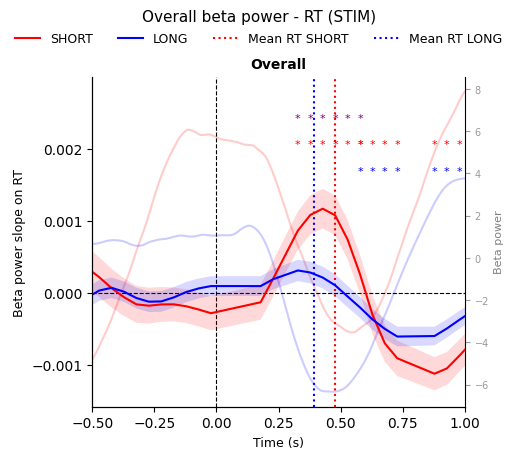

In [6]:
## Plot 1 — Overall trends + significance windows
trends  = pd.read_csv(data_dir / "beta_power_STIM_RT_trends.csv")
windows = pd.read_csv(data_dir / "beta_power_STIM_RT_windows.csv")

trends = trends[trends["SE"].apply(lambda x: pd.notna(x) and np.isfinite(x) and x != 0)]

mean_rt = (
    trials.dropna(subset=["response_time"])
    .groupby("condition")["response_time"]
    .mean()
)
print("Mean RT per condition (s):")
print(mean_rt)

# ── Grand-average beta power per condition (background) ───────────────────────
time_cols = [c for c in trials.columns if c.startswith("time_")]
time_vals = np.array([float(c.replace("time_", "")) for c in time_cols])
t_mask    = (time_vals >= XLIM[0]) & (time_vals <= XLIM[1])

grand_pow = (
    trials.groupby(["condition", "subject_id"])[time_cols].mean()
    .groupby("condition").mean()
)

trends_vis = trends[trends["time"].between(*XLIM)]
y_min  = trends_vis["estimate"].min()
y_max  = trends_vis["estimate"].max()
y_span = y_max - y_min
y_pad  = 0.2 * y_span

py_long  = y_max + 1.0 * y_pad
py_short = y_max + 1.8 * y_pad
py_ctr   = y_max + 2.6 * y_pad

fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)

ax2 = ax.twinx()
ax2.set_zorder(ax.get_zorder() - 1)
ax.patch.set_visible(False)

for cond, color in CONDITION_COLORS.items():
    ax2.plot(time_vals[t_mask], grand_pow.loc[cond].values[t_mask],
             color=color, linewidth=1.5, alpha=0.2, zorder=0)

ax2.set_ylabel("Beta power", fontsize=8, color="0.5")
ax2.tick_params(axis="y", labelsize=7, colors="0.6")
ax2.spines[["top"]].set_visible(False)

ax.axhline(0, color="k", linestyle="--", linewidth=0.8, zorder=1)
ax.axvline(0, color="k", linestyle="--", linewidth=0.8, zorder=1)

for cond, color in CONDITION_COLORS.items():
    if cond in mean_rt.index:
        ax.vlines(mean_rt[cond], ymin=y_min - y_pad, ymax=0.01,
                  color=color, linestyle=":", linewidth=1.5, zorder=2)

for cond, color in CONDITION_COLORS.items():
    cdf = trends[trends["condition"] == cond].sort_values("time")
    ax.fill_between(
        cdf["time"],
        cdf["estimate"] - cdf["SE"],
        cdf["estimate"] + cdf["SE"],
        color=color, alpha=ALPHA, linewidth=0,
    )
    ax.plot(cdf["time"], cdf["estimate"],
            color=color, linewidth=1.5, label=cond)

ax.set_ylim(y_min - y_pad, y_max + 4 * y_pad)

for _, win in windows.iterrows():
    mask      = (trends["time"] >= win["start"]) & (trends["time"] <= win["end"])
    win_times = trends[mask]["time"].unique()
    win_times = win_times[(win_times >= XLIM[0]) & (win_times <= XLIM[1])]
    for t in win_times:
        if win["long_p"] < 0.05:
            ax.text(t, py_long,  "*", color=long_color,  ha="center", va="bottom", fontsize=8)
        if win["short_p"] < 0.05:
            ax.text(t, py_short, "*", color=short_color, ha="center", va="bottom", fontsize=8)
        if win["long_short_p"] < 0.05:
            ax.text(t, py_ctr,   "*", color="purple",    ha="center", va="bottom", fontsize=8)

ax.set_xlim(XLIM)
ax.set_title("Overall", fontweight="bold", fontsize=10)
ax.set_xlabel("Time (s)", fontsize=9)
ax.set_ylabel("Beta power slope on RT", fontsize=9)
ax.xaxis.set_major_locator(plt.MaxNLocator(6))
ax.spines[["top", "right"]].set_visible(False)

handles, labels = ax.get_legend_handles_labels()
for cond, color in CONDITION_COLORS.items():
    handles.append(plt.Line2D([0], [0], color=color, linestyle=":", linewidth=1.5))
    labels.append(f"Mean RT {cond}")

fig.legend(handles, labels,
           loc="upper center", ncol=len(CONDITION_COLORS) * 2,
           frameon=False, fontsize=9,
           bbox_to_anchor=(0.5, 1.08))

fig.suptitle(f"Overall beta power - RT ({epoch})", fontsize=11, y=1.11)

out_path = data_dir / f"beta_power_{epoch}_RT_overall_perm.pdf"
fig.savefig(out_path, bbox_inches="tight", dpi=150)
print(f"Saved -> {out_path}")
plt.show()